# Coding Assignment 1: Introduction to Linear Regression

**Name:** HANNAH DEAN  
**Student ID:** 784361  
**Date:** 10/1/2026  

## Overview

Welcome to your first machine learning assignment! In this notebook, you'll journey from mathematical foundations to practical implementation of linear regression. You'll build your own linear regression from scratch, then compare it with professional ML libraries.

**Learning Goals:**
- Understand linear regression mathematics
- Implement gradient descent from scratch
- Apply ML to real housing price data
- Reflect on ML vs. traditional programming

**Estimated Time:** 2 hours

## Part 1: Mathematical Foundation (30 minutes)

Before we code, let's understand the mathematics behind linear regression.

In [4]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
NumPy version: 2.1.3


### 1.1 Understanding the Linear Equation

Linear regression finds the best line through data points. For one feature:

**y = mx + b**

For multiple features:

**y = θ₀ + θ₁x₁ + θ₂x₂ + ... + θₙxₙ**

Or in vector form: **y = X·θ**

Where:
- **y** = predicted value
- **X** = feature matrix
- **θ** = parameters (weights)


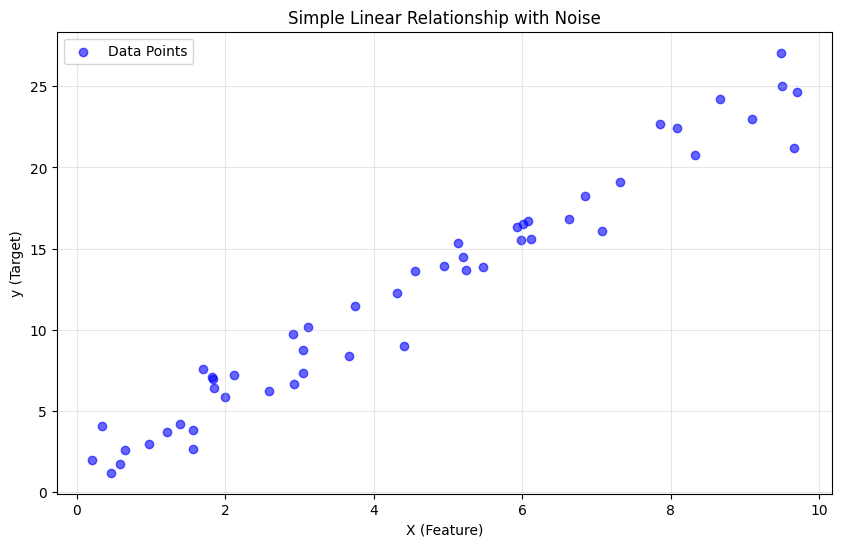

Data shape: (50, 1)
Target shape: (50,)


In [5]:
# Let's create some simple synthetic data to visualize linear regression
np.random.seed(42)
X_simple = np.random.rand(50, 1) * 10  # 50 random points between 0 and 10
y_simple = 2.5 * X_simple.flatten() + 1.0 + np.random.randn(50) * 1.5  # y = 2.5x + 1 + noise

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_simple, alpha=0.6, color='blue', label='Data Points')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Simple Linear Relationship with Noise')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Data shape: {X_simple.shape}")
print(f"Target shape: {y_simple.shape}")

### 1.2 The Cost Function

We need to measure how "wrong" our predictions are. The **Mean Squared Error (MSE)** cost function is:

**J(θ) = (1/2m) × Σ(hθ(x⁽ⁱ⁾) - y⁽ⁱ⁾)²**

Where:
- **m** = number of training examples
- **hθ(x⁽ⁱ⁾)** = prediction for example i
- **y⁽ⁱ⁾** = actual value for example i

In [6]:
def compute_cost(X, y, theta):
    """
    Compute the mean squared error cost function.

    Parameters:
    X (array): Feature matrix with bias column
    y (array): Target values
    theta (array): Parameters [bias, weight1, weight2, ...]

    Returns:
    cost (float): Mean squared error
    """
    m = len(y)  # number of examples

    # TODO: Calculate predictions using X @ theta (matrix multiplication)
    predictions = X @ theta  # Replace None with your code

    # TODO: Calculate errors (predictions - actual values)
    errors = predictions - y  # Replace None with your code

    # TODO: Square the errors
    squared_errors = errors ** 2  # Replace None with your code

    # TODO: Calculate mean squared error: (1/2m) * sum of squared errors
    cost = (1/(2*m)) * np.sum(squared_errors) # Replace None with your code

    return cost

# Test the cost function when you're done
# Add bias column to X_simple
X_simple_with_bias = np.column_stack([np.ones(X_simple.shape[0]), X_simple])

# Test with random parameters
test_theta = np.array([0.0, 1.0])  # [bias, weight]

# TODO: Uncomment the next line after implementing the function
test_cost = compute_cost(X_simple_with_bias, y_simple, test_theta)
print(f"Test cost with theta=[0, 1]: {test_cost:.4f}")

Test cost with theta=[0, 1]: 39.2455


### 1.3 Gradient Descent

To minimize the cost function, we use **gradient descent**. We update parameters iteratively:

**θⱼ := θⱼ - α × (∂J(θ)/∂θⱼ)**

For linear regression, the gradient is:

**∂J(θ)/∂θⱼ = (1/m) × Σ(hθ(x⁽ⁱ⁾) - y⁽ⁱ⁾) × xⱼ⁽ⁱ⁾**

Where **α** is the learning rate.

In [7]:
def compute_gradients(X, y, theta):
    """
    Compute gradients for gradient descent.

    Parameters:
    X (array): Feature matrix with bias column
    y (array): Target values
    theta (array): Current parameters

    Returns:
    gradients (array): Gradients for each parameter
    """
    m = len(y)  # number of examples

    # TODO: Calculate predictions using X @ theta
    predictions = X @ theta  # Replace None with your code

    # TODO: Calculate errors (predictions - actual values)
    errors = predictions - y  # Replace None with your code

    # TODO: Calculate gradients using matrix operations
    # Hint: The gradient formula is (1/m) * X.T @ errors
    gradients = (1/m) * X.T @ errors   # Replace None with your code

    return gradients

# TODO: Test gradient computation after implementing the function
# Uncomment the lines below:
test_gradients = compute_gradients(X_simple_with_bias, y_simple, test_theta)
print(f"Gradients with theta=[0, 1]: {test_gradients}")
print(f"Gradient for bias: {test_gradients[0]:.4f}")
print(f"Gradient for weight: {test_gradients[1]:.4f}")

Gradients with theta=[0, 1]: [ -7.68444064 -46.26032144]
Gradient for bias: -7.6844
Gradient for weight: -46.2603


## Part 2: From-Scratch Implementation (45 minutes)

Now let's build our own Linear Regression class!

In [8]:
class LinearRegression:
    """
    Linear Regression implementation using gradient descent.
    """

    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        """
        Initialize the Linear Regression model.

        Parameters:
        learning_rate (float): Step size for gradient descent
        max_iterations (int): Maximum number of iterations
        tolerance (float): Convergence tolerance
        """
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.theta = None
        self.cost_history = []

    def _add_bias_column(self, X):
        """
        Add bias column (column of ones) to feature matrix.

        Parameters:
        X (array): Feature matrix

        Returns:
        X_with_bias (array): Feature matrix with bias column
        """
        # TODO: Create a column of ones and add it to the beginning of X
        # Hint: Use np.ones() and np.column_stack()
        bias_column = np.ones(X.shape[0])  # Replace None with your code
        X_with_bias = np.column_stack([bias_column, X])  # Replace None with your code
        return X_with_bias

    def fit(self, X, y):
        """
        Train the linear regression model using gradient descent.

        Parameters:
        X (array): Training features
        y (array): Training targets
        """
        # Add bias column
        X_with_bias = self._add_bias_column(X)

        # Initialize parameters
        n_features = X_with_bias.shape[1]
        # TODO: Initialize theta with small random values
        # Hint: Use np.random.normal(0, 0.01, n_features)
        self.theta = np.random.normal(0, 0.01, n_features)  # Replace None with your code

        # Gradient descent
        self.cost_history = []

        for iteration in range(self.max_iterations):
            # TODO: Compute current cost using the compute_cost function
            current_cost = compute_cost(X_with_bias, y, self.theta)  # Replace None with your code
            self.cost_history.append(current_cost)

            # TODO: Compute gradients using the compute_gradients function
            gradients = compute_gradients(X_with_bias, y, self.theta)  # Replace None with your code

            # TODO: Update parameters using gradient descent rule
            # New theta = old theta - learning_rate * gradients
            new_theta = self.theta - self.learning_rate * gradients  # Replace None with your code

            # Check for convergence
            converged = np.allclose(self.theta, new_theta, atol=self.tolerance)
            self.theta = new_theta
            if converged:
                print(f"Converged after {iteration + 1} iterations")
                break

            # Print progress every 100 iterations
            if (iteration + 1) % 100 == 0:
                print(f"Iteration {iteration + 1}: Cost = {current_cost:.6f}")

    def predict(self, X):
        """
        Make predictions using the trained model.

        Parameters:
        X (array): Features to predict

        Returns:
        predictions (array): Predicted values
        """
        if self.theta is None:
            raise Exception("Model must be trained first. Call fit() method.")

        # TODO: Add bias column and make predictions
        # Hint: Use self._add_bias_column() and matrix multiplication
        X_with_bias = self._add_bias_column(X)  # Replace None with your code
        predictions = X_with_bias @ self.theta  # Replace None with your code

        return predictions

    def score(self, X, y):
        """
        Calculate R-squared score.

        Parameters:
        X (array): Features
        y (array): True values

        Returns:
        r2 (float): R-squared score
        """
        y_pred = self.predict(X)

        # TODO: Calculate R-squared using the formula: 1 - (SS_res / SS_tot)
        # SS_res = sum of squared residuals = sum((y_true - y_pred)^2)
        # SS_tot = total sum of squares = sum((y_true - y_mean)^2)
        ss_res = np.sum((y- y_pred) ** 2)  # Replace None with your code
        ss_tot = np.sum((y - np.mean(y))** 2)  # Replace None with your code
        r2 = 1 - (ss_res / ss_tot)  # Replace None with your code

        return r2

print("LinearRegression class defined successfully!")
print("TODO: Complete the missing implementations in the methods above")


LinearRegression class defined successfully!
TODO: Complete the missing implementations in the methods above


### 2.1 Test Your Implementation

Let's test your linear regression on the synthetic data we created earlier.

In [9]:
# TODO: After implementing your LinearRegression class, uncomment and run this code

# Create and train our model
print("Training our from-scratch Linear Regression...")
# NOTE: X_simple is unscaled (values 0-10), so gradient descent needs a small
# step size here — lr=0.1 diverges on this data. The housing cells later use
# lr=0.1 safely because those features are standardised first.
our_model = LinearRegression(learning_rate=0.01, max_iterations=1000)
our_model.fit(X_simple, y_simple)

# Make predictions
y_pred_ours = our_model.predict(X_simple)

# Calculate metrics
our_r2 = our_model.score(X_simple, y_simple)
our_mse = mean_squared_error(y_simple, y_pred_ours)

print(f"\nOur Model Results:")
print(f"Final parameters (theta): {our_model.theta}")
print(f"R² Score: {our_r2:.4f}")
print(f"MSE: {our_mse:.4f}")
print(f"Bias (intercept): {our_model.theta[0]:.4f}")
print(f"Weight (slope): {our_model.theta[1]:.4f}")

print("TODO: Uncomment the code above after implementing your LinearRegression class")

Training our from-scratch Linear Regression...
Iteration 100: Cost = 0.970271
Iteration 200: Cost = 0.951037
Iteration 300: Cost = 0.940152
Iteration 400: Cost = 0.933990
Iteration 500: Cost = 0.930503
Iteration 600: Cost = 0.928529
Iteration 700: Cost = 0.927412
Iteration 800: Cost = 0.926780
Iteration 900: Cost = 0.926422
Iteration 1000: Cost = 0.926219

Our Model Results:
Final parameters (theta): [1.10258233 2.47329944]
R² Score: 0.9641
MSE: 1.8524
Bias (intercept): 1.1026
Weight (slope): 2.4733
TODO: Uncomment the code above after implementing your LinearRegression class


In [10]:
# Compare with scikit-learn (this will work regardless of your implementation)
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X_simple, y_simple)
y_pred_sklearn = sklearn_model.predict(X_simple)

sklearn_r2 = sklearn_model.score(X_simple, y_simple)
sklearn_mse = mean_squared_error(y_simple, y_pred_sklearn)

print(f"Scikit-learn Results:")
print(f"R² Score: {sklearn_r2:.4f}")
print(f"MSE: {sklearn_mse:.4f}")
print(f"Bias (intercept): {sklearn_model.intercept_:.4f}")
print(f"Weight (slope): {sklearn_model.coef_[0]:.4f}")

# TODO: Uncomment the comparison code below after implementing your model
print(f"\nComparison:")
print(f"R² difference: {abs(our_r2 - sklearn_r2):.6f}")
print(f"MSE difference: {abs(our_mse - sklearn_mse):.6f}")

Scikit-learn Results:
R² Score: 0.9641
MSE: 1.8519
Bias (intercept): 1.1450
Weight (slope): 2.4665

Comparison:
R² difference: 0.000010
MSE difference: 0.000525


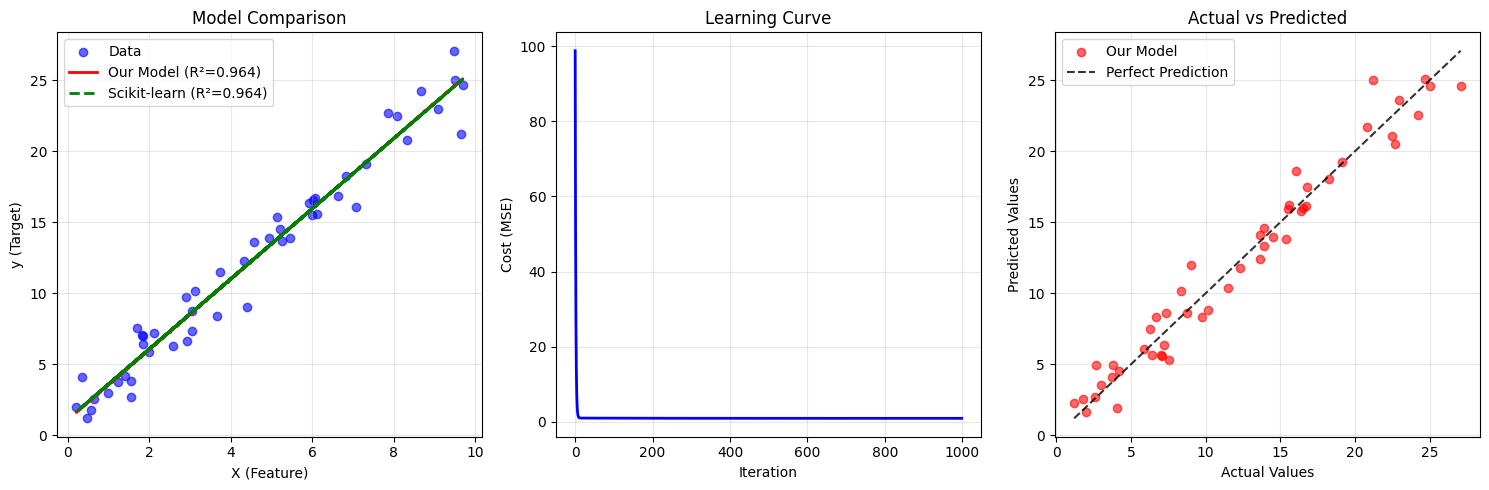

TODO: Uncomment the visualization code above after implementing your LinearRegression class


In [11]:
# TODO: Uncomment and complete this visualization code after implementing your model

# Visualize the results
plt.figure(figsize=(15, 5))

# # Plot 1: Data and predictions
plt.subplot(1, 3, 1)
plt.scatter(X_simple, y_simple, alpha=0.6, color='blue', label='Data')
plt.plot(X_simple, y_pred_ours, 'r-', label=f'Our Model (R²={our_r2:.3f})', linewidth=2)
plt.plot(X_simple, y_pred_sklearn, 'g--', label=f'Scikit-learn (R²={sklearn_r2:.3f})', linewidth=2)
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# # Plot 2: Cost function history
plt.subplot(1, 3, 2)
plt.plot(our_model.cost_history, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Learning Curve')
plt.grid(True, alpha=0.3)

# # Plot 3: Actual vs Predicted
plt.subplot(1, 3, 3)
min_val = min(y_simple.min(), y_pred_ours.min())
max_val = max(y_simple.max(), y_pred_ours.max())
plt.scatter(y_simple, y_pred_ours, alpha=0.6, color='red', label='Our Model')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("TODO: Uncomment the visualization code above after implementing your LinearRegression class")

### 2.2 Reflection Questions

**TODO: Answer these questions in the markdown cells below:**

1. How close are your results to scikit-learn's implementation?
2. What do you notice about the convergence of the cost function?
3. What happens if you change the learning rate? Try different values.

**Your Answer for Question 1:**

My results appear extremelly close to the scikit-learn's implementation. Both of them had the Same R^2 score of .9641. The difference in MSE is roughly .0005. The intercept and the slope were also very similar. My gradient descent implementation was able to produce almost the same regression model as scikit-learn.

**Your Answer for Question 2:**

The cost function decreased very quickly during the first few iterations and leveled off close to its minimum. The gradient descent was successfully reducing the error and coveraging. After the large decrease initialy , the changes became small because the model was already close to the optimal parameters.

**Your Answer for Question 3:**

Changing the learning rate affects how quickly gradient descent converges. With a smaller learning rate, such as 0.001, the model learns more slowly and requires more iterations to reach a good solution. It gave us a R^2 of .9624 & MSE of 1.9394
If the learning rate is increased too much, such as 0.1 with this unscaled dataset, the updates can become too large and cause the cost to increase or diverge instead of converging. R^2 and MSE went to INF

## Part 3: Real-World Application (30 minutes)

Now let's apply our linear regression to real housing price data!

In [13]:
import tarfile
import numpy as np
import pandas as pd

# Open the downloaded sklearn dataset
with tarfile.open("cal_housing.tgz", "r:gz") as f:
    cal_housing = np.loadtxt(
        f.extractfile("CaliforniaHousing/cal_housing.data"),
        delimiter=","
    )

# Put columns in the same order sklearn uses
columns_index = [8, 7, 2, 3, 4, 5, 6, 1, 0]
cal_housing = cal_housing[:, columns_index]

feature_names = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude"
]

# Separate target and features
y_california = cal_housing[:, 0]
X_california = cal_housing[:, 1:]

# Perform the SAME transformations sklearn performs
X_california[:, 2] /= X_california[:, 5]
X_california[:, 3] /= X_california[:, 5]
X_california[:, 5] = X_california[:, 4] / X_california[:, 5]

# Target is measured in $100,000 units
y_california = y_california / 100000.0

# Create dataframe
df_california = pd.DataFrame(
    X_california,
    columns=feature_names
)

df_california["PRICE"] = y_california

print(f"Dataset shape: {X_california.shape}")
print(f"Features: {feature_names}")
print(
    f"Target range: {y_california.min():.1f} - "
    f"{y_california.max():.1f} (in $100K units)"
)

print("\nFirst few samples:")
print(df_california.head())

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: 0.1 - 5.0 (in $100K units)

First few samples:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


### 3.1 Data Exploration

Let's understand our data before applying machine learning.

In [14]:
# Basic statistics
print("Dataset Statistics:")
print(df_california.describe())

# Check for missing values
print(f"\nMissing values: {df_california.isnull().sum().sum()}")

Dataset Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         PRICE  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0

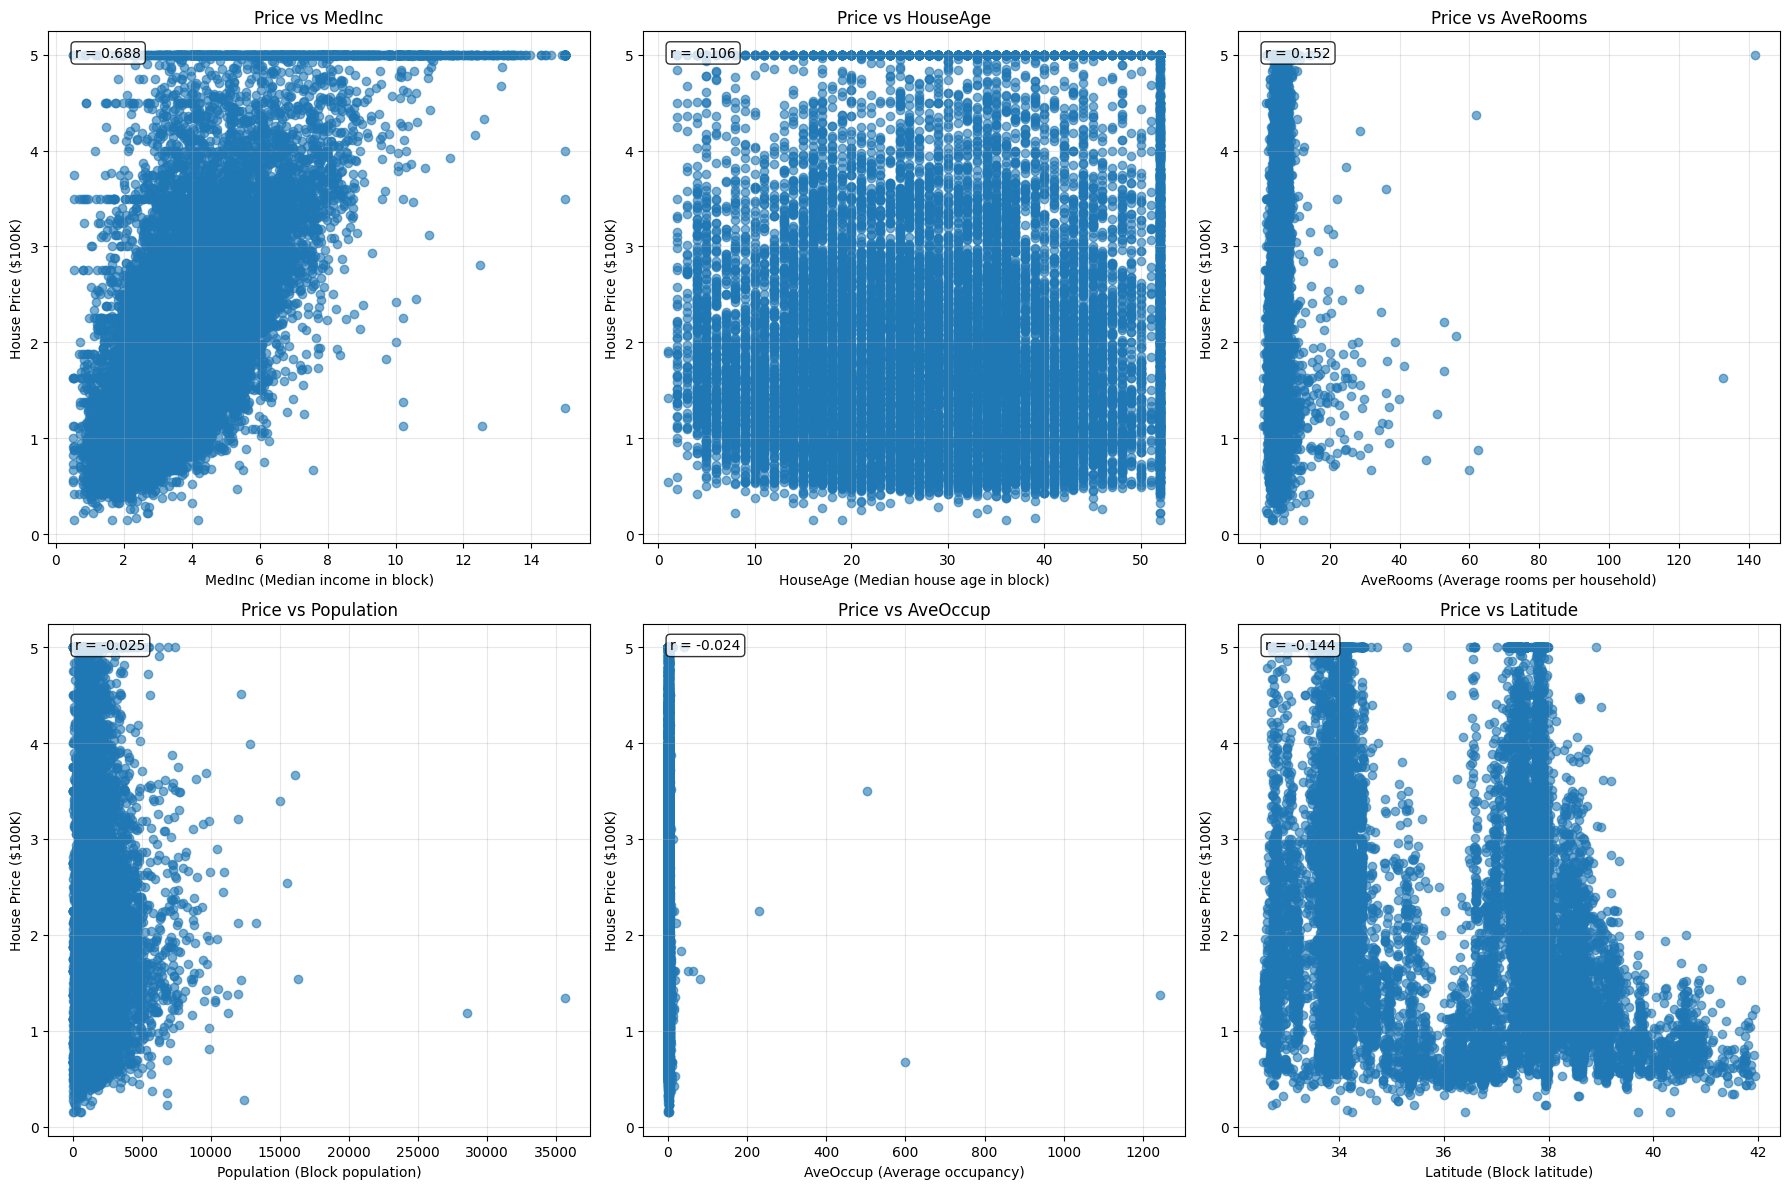

In [15]:
# Visualize some key relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Select some interesting features to plot
interesting_features = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude']
feature_descriptions = {
    'MedInc': 'Median income in block',
    'HouseAge': 'Median house age in block',
    'AveRooms': 'Average rooms per household',
    'Population': 'Block population',
    'AveOccup': 'Average occupancy',
    'Latitude': 'Block latitude'
}

for i, feature in enumerate(interesting_features):
    axes[i].scatter(df_california[feature], df_california['PRICE'], alpha=0.6)
    axes[i].set_xlabel(f'{feature} ({feature_descriptions[feature]})')
    axes[i].set_ylabel('House Price ($100K)')
    axes[i].set_title(f'Price vs {feature}')
    axes[i].grid(True, alpha=0.3)

    # Calculate correlation
    correlation = np.corrcoef(df_california[feature], df_california['PRICE'])[0, 1]
    axes[i].text(0.05, 0.95, f'r = {correlation:.3f}',
                transform=axes[i].transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### 3.2 Data Preprocessing

For gradient descent to work well, we need to scale our features.

In [16]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_california, y_california, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling applied:")
print(f"Original range - min: {X_train.min():.2f}, max: {X_train.max():.2f}")
print(f"Scaled range - min: {X_train_scaled.min():.2f}, max: {X_train_scaled.max():.2f}")
print(f"Scaled mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")

Training set: 16512 samples
Test set: 4128 samples

Feature scaling applied:
Original range - min: -124.35, max: 35682.00
Scaled range - min: -2.38, max: 107.12
Scaled mean: -0.000000, std: 1.000000


### 3.3 Apply Both Implementations

In [17]:
# Train our from-scratch model
print("Training our Linear Regression on housing data...")
our_housing_model = LinearRegression(learning_rate=0.1, max_iterations=2000)
our_housing_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_ours = our_housing_model.predict(X_train_scaled)
y_test_pred_ours = our_housing_model.predict(X_test_scaled)

# Calculate metrics for our model
our_train_r2 = our_housing_model.score(X_train_scaled, y_train)
our_test_r2 = our_housing_model.score(X_test_scaled, y_test)
our_train_mse = mean_squared_error(y_train, y_train_pred_ours)
our_test_mse = mean_squared_error(y_test, y_test_pred_ours)

print(f"\nOur Model - Housing Data Results:")
print(f"Training R²: {our_train_r2:.4f}")
print(f"Test R²: {our_test_r2:.4f}")
print(f"Training MSE: {our_train_mse:.4f}")
print(f"Test MSE: {our_test_mse:.4f}")

Training our Linear Regression on housing data...
Iteration 100: Cost = 0.273637
Iteration 200: Cost = 0.262247
Iteration 300: Cost = 0.259781
Iteration 400: Cost = 0.259196
Iteration 500: Cost = 0.259039
Iteration 600: Cost = 0.258991
Iteration 700: Cost = 0.258976
Iteration 800: Cost = 0.258970
Iteration 900: Cost = 0.258968
Iteration 1000: Cost = 0.258967
Iteration 1100: Cost = 0.258967
Converged after 1166 iterations

Our Model - Housing Data Results:
Training R²: 0.6126
Test R²: 0.5757
Training MSE: 0.5179
Test MSE: 0.5559


In [18]:
# Train scikit-learn model for comparison
print("Training scikit-learn model...")
sklearn_housing_model = SklearnLinearRegression()
sklearn_housing_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_sklearn = sklearn_housing_model.predict(X_train_scaled)
y_test_pred_sklearn = sklearn_housing_model.predict(X_test_scaled)

# Calculate metrics
sklearn_train_r2 = sklearn_housing_model.score(X_train_scaled, y_train)
sklearn_test_r2 = sklearn_housing_model.score(X_test_scaled, y_test)
sklearn_train_mse = mean_squared_error(y_train, y_train_pred_sklearn)
sklearn_test_mse = mean_squared_error(y_test, y_test_pred_sklearn)

print(f"Scikit-learn - Housing Data Results:")
print(f"Training R²: {sklearn_train_r2:.4f}")
print(f"Test R²: {sklearn_test_r2:.4f}")
print(f"Training MSE: {sklearn_train_mse:.4f}")
print(f"Test MSE: {sklearn_test_mse:.4f}")

print(f"\nModel Comparison:")
print(f"Test R² difference: {abs(our_test_r2 - sklearn_test_r2):.6f}")
print(f"Test MSE difference: {abs(our_test_mse - sklearn_test_mse):.6f}")

Training scikit-learn model...
Scikit-learn - Housing Data Results:
Training R²: 0.6126
Test R²: 0.5758
Training MSE: 0.5179
Test MSE: 0.5559

Model Comparison:
Test R² difference: 0.000040
Test MSE difference: 0.000052


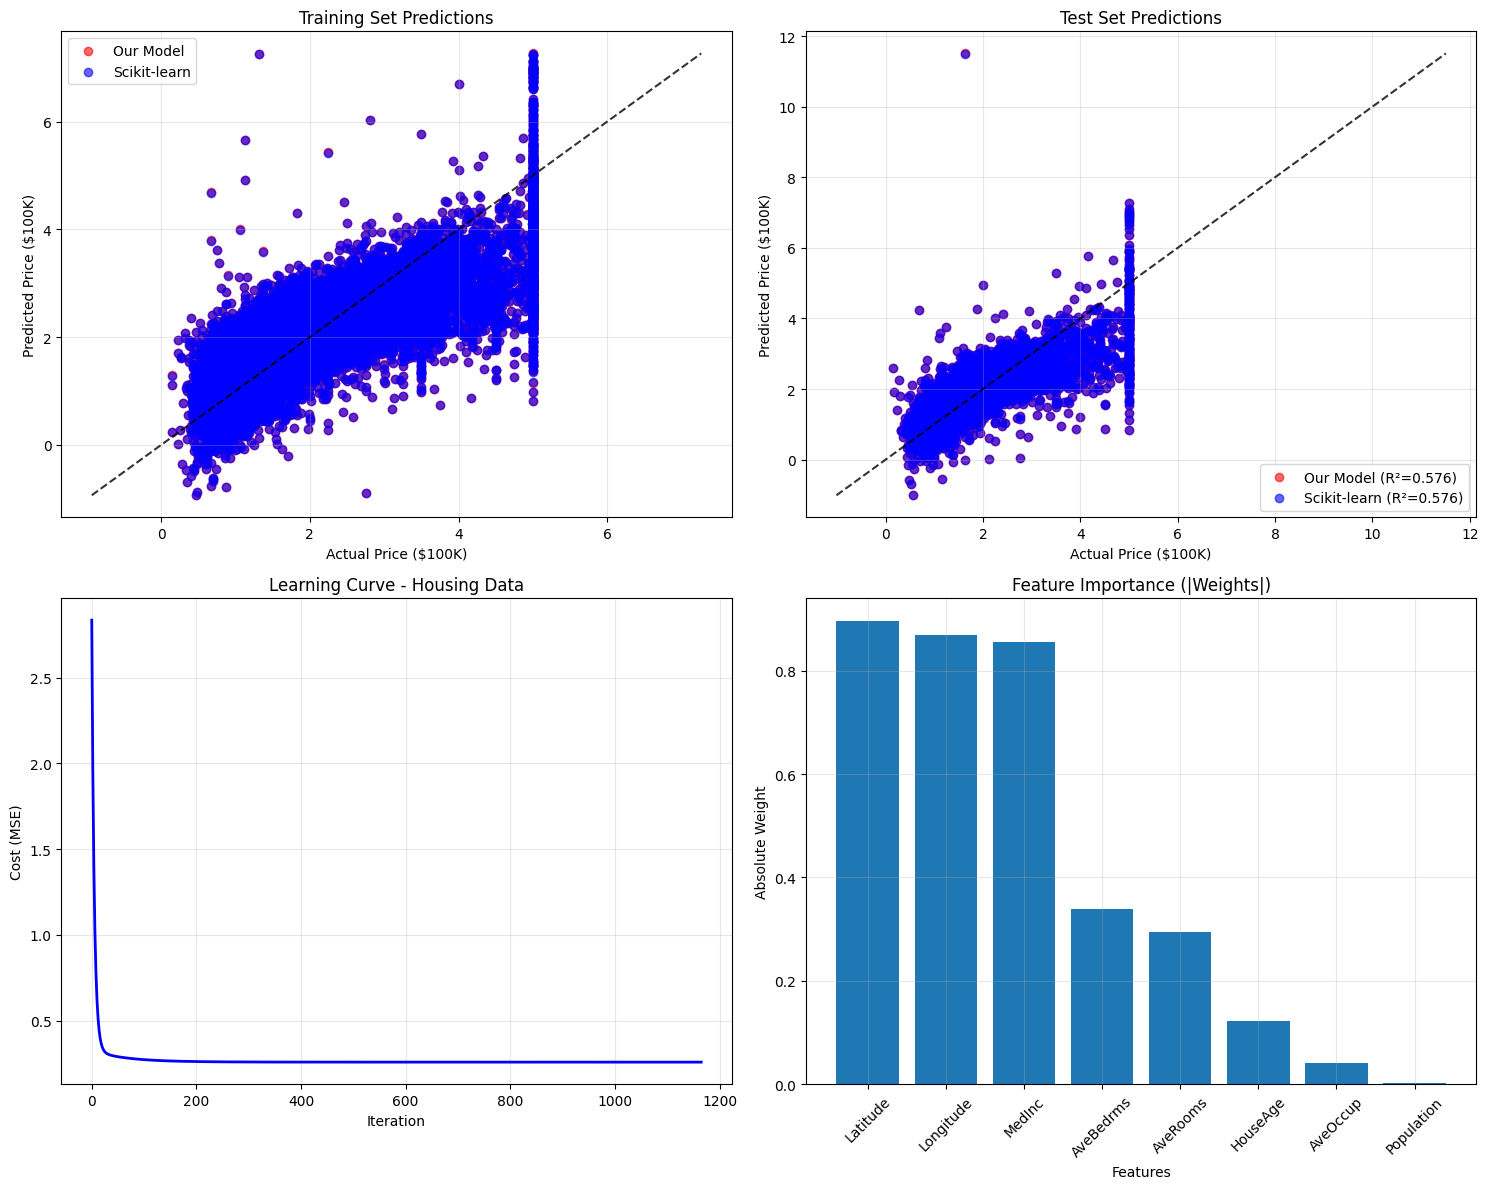

In [19]:
# Visualize housing data results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training predictions
axes[0, 0].scatter(y_train, y_train_pred_ours, alpha=0.6, color='red', label='Our Model')
axes[0, 0].scatter(y_train, y_train_pred_sklearn, alpha=0.6, color='blue', label='Scikit-learn')
min_val = min(y_train.min(), y_train_pred_ours.min())
max_val = max(y_train.max(), y_train_pred_ours.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8)
axes[0, 0].set_xlabel('Actual Price ($100K)')
axes[0, 0].set_ylabel('Predicted Price ($100K)')
axes[0, 0].set_title(f'Training Set Predictions')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Test predictions
axes[0, 1].scatter(y_test, y_test_pred_ours, alpha=0.6, color='red', label=f'Our Model (R²={our_test_r2:.3f})')
axes[0, 1].scatter(y_test, y_test_pred_sklearn, alpha=0.6, color='blue', label=f'Scikit-learn (R²={sklearn_test_r2:.3f})')
min_val = min(y_test.min(), y_test_pred_ours.min())
max_val = max(y_test.max(), y_test_pred_ours.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8)
axes[0, 1].set_xlabel('Actual Price ($100K)')
axes[0, 1].set_ylabel('Predicted Price ($100K)')
axes[0, 1].set_title('Test Set Predictions')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Learning curve
axes[1, 0].plot(our_housing_model.cost_history, 'b-', linewidth=2)
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Cost (MSE)')
axes[1, 0].set_title('Learning Curve - Housing Data')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature importance (weights)
feature_weights = our_housing_model.theta[1:]  # Exclude bias term
sorted_indices = np.argsort(np.abs(feature_weights))[::-1]
axes[1, 1].bar(range(len(feature_weights)), np.abs(feature_weights)[sorted_indices])
axes[1, 1].set_xlabel('Features')
axes[1, 1].set_ylabel('Absolute Weight')
axes[1, 1].set_title('Feature Importance (|Weights|)')
axes[1, 1].set_xticks(range(len(feature_weights)))
axes[1, 1].set_xticklabels([feature_names[i] for i in sorted_indices], rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Analysis Questions

**TODO: Answer these questions based on your results:**

**1. How well does your model perform on the housing data? What does the R² score tell you?**

My model performs moderately well on the housing data. The training R^2 was .6126 and the test R^2 was .5757. Meaning the model explains 57% of variation in housing prices on the unseen test data.

**2. Which features seem most important for predicting house prices? Look at the feature weights.**

Based on the absolute feature weights, latitude, longitude, and MedInc appear to be the most important predictors. With Latitude having the largest weight. Becuase they were standardized before training the weights are easier to comare.

**3. How do training and test performance compare? What does this suggest about your model?**

The model performed slightly better on the training data than the testing data. With the training having a R^2 of .6126 and the testing having a R^2 of .5757. Because the difference is small the model doesnt appear to be overfitting. However the linear regression model cant capture all of the complex relationships in housing prices.

## Part 4: Critical Reflection (15 minutes)

Now let's reflect on the bigger picture: How does machine learning differ from traditional programming?

### 4.1 ML vs Traditional Programming

**Traditional Programming:**
- We write explicit rules and logic
- Input + Program → Output
- Deterministic and predictable
- Example: `if temperature > 80: recommend_shorts()`

**Machine Learning:**
- We provide examples and let the algorithm learn patterns
- Input + Output → Program (Model)
- Statistical and probabilistic
- Example: Learn from 10,000 weather/clothing combinations

**TODO: Provide a specific example from your housing price prediction experience:**



**Example from Housing Prediction:**

**Traditional Programming Approach:**
Traditional programming causes you mto have to manually create rules for how each feature affects housing prices. For example, I might have to write rules saying that a higher median income increases the predicted price. I would have to decide the size and importance of each adjustment myself.

**Machine Learning Approach:**
WIth machine learning you give the model the features and actual prices, and gradient descent learned the weight that minimized prediction error. The model then learned the features like median income, latitude, and longitude were important based on patterns in the training data.

### 4.2 When to Use Machine Learning

**TODO: Based on your experience, answer these questions:**

**1. When would you choose machine learning over traditional programming?**

I would use machine learning when there is a large amount of data and the relationship between the inputs and outcome is too complicated to define with a set of rules.

**2. When would traditional programming be better than machine learning?**

Traditional programming would be better when the rules are already known and clearly defined.

**3. What are the main challenges you encountered with machine learning in this assignment?**

One challenge was understanding how the learning rate affected gradient descent. If it was too large, the model could diverge, while a smaller learning rate took longer to converge.

### 4.3 Limitations of Linear Regression

**TODO: Reflect on what you've learned:**

**1. What assumptions does linear regression make? When might these be violated?**

Linear regression assumes that there is a linear relationship between the features and the target, that observations are independent, and that the errors have relatively constant variance. These assumptions can be violated with housing data because housing prices are influenced by complicated relationships.

**2. How could you improve your housing price predictions?**

I could try models that can capture nonlinear relationships, such as random forests, gradient boosting, or neural networks

## Bonus: Experimentation (Optional)

If you have extra time, try these experiments:

In [ ]:
# Bonus 1: Try different learning rates
learning_rates = [0.001, 0.01, 0.1, 1.0]
results = []

for lr in learning_rates:
    model = LinearRegression(learning_rate=lr, max_iterations=1000)
    model.fit(X_train_scaled, y_train)
    test_r2 = model.score(X_test_scaled, y_test)
    results.append((lr, test_r2, len(model.cost_history)))
    print(f"Learning rate {lr}: R² = {test_r2:.4f}, Iterations = {len(model.cost_history)}")

# TODO: What do you observe about different learning rates?

**Observations about Learning Rates:**

[TODO: Write your observations here]

In [ ]:
# Bonus 2: Feature selection - try using only the most important features
# Get the top 5 most important features
feature_weights = our_housing_model.theta[1:]  # Exclude bias
top_features_idx = np.argsort(np.abs(feature_weights))[::-1][:5]

print(f"Top 5 most important features:")
for i, idx in enumerate(top_features_idx):
    print(f"{i+1}. {feature_names[idx]}: weight = {feature_weights[idx]:.4f}")

# Train model with only top features
X_train_top = X_train_scaled[:, top_features_idx]
X_test_top = X_test_scaled[:, top_features_idx]

top_model = LinearRegression(learning_rate=0.1, max_iterations=1000)
top_model.fit(X_train_top, y_train)

top_test_r2 = top_model.score(X_test_top, y_test)
print(f"\nR² with all features: {our_test_r2:.4f}")
print(f"R² with top 5 features: {top_test_r2:.4f}")
print(f"Difference: {our_test_r2 - top_test_r2:.4f}")

## Summary and Submission

### What You've Accomplished

Congratulations! In this assignment, you have:

✅ **Understood the mathematics** behind linear regression  
✅ **Implemented gradient descent** from scratch  
✅ **Built a complete ML pipeline** for housing price prediction  
✅ **Compared your implementation** with professional libraries  
✅ **Reflected critically** on ML vs traditional programming  

### Key Takeaways

**TODO: Write 2-3 key insights from this assignment:**

1. [TODO: Your first key takeaway]
2. [TODO: Your second key takeaway]  
3. [TODO: Your third key takeaway]

### Final Reflection

**TODO: Write a brief (100-150 words) final reflection on your experience with this assignment:**

[TODO: Your final reflection here]

---

**Assignment Complete!**

Make sure to:
1. Save your notebook
2. Export as HTML
3. Submit both .ipynb and .html files
4. Include your name and student ID at the top